# 03 — Flood-susceptibility model + interpretable drivers

Predict `flood_count` from the ward × year panel and read off **which drivers matter**.

* model — gradient-boosting regressor on `log1p(flood_count)`
* validation — two honest bookends: **in-distribution** 5-fold CV, and an **extrapolation**
  stress test that trains on 2005–2018 and predicts the unseen 2019–2022
* interpretability — **SHAP** mean(|value|) per feature (falls back to permutation importance
  if SHAP is unavailable), with a focus on the hidden-river × weak-sewer × rainfall interactions

> **Draft caveat.** 25 wards × 18 years is a small panel and rainfall is city-wide (no spatial
> variation), so the model extrapolates poorly across years even though the features carry clear
> in-distribution signal. Treat the susceptibility surface as indicative, not operational.

Outputs `shap_importances.csv` (driver bar chart) and `ward_susceptibility.csv` (per-ward
predicted susceptibility at recent-typical rainfall) — both read by the app's **Risk Hotspots** tab.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parents[0]))
import lib
import numpy as np, pandas as pd
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 40)

# Panel from notebook 01 (rebuild if not yet saved)
p = lib.processed_dir() / 'ward_year_panel.csv'
panel = pd.read_csv(p) if p.exists() else lib.build_panel()
print('panel:', panel.shape, '| features:', len(lib.MODEL_FEATURES))
panel[['ward_num','year','flood_count']].head(3)

panel: (450, 26) | features: 20


,ward_num,year,flood_count
0,1,2005,180.0
1,2,2005,183.0
2,3,2005,130.0


## Train / validate (held-out recent years)

In [2]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict

X = panel[lib.MODEL_FEATURES]
y = np.log1p(panel['flood_count'])

def make_model():
    return GradientBoostingRegressor(n_estimators=400, max_depth=3,
                                     learning_rate=0.05, subsample=0.9, random_state=0)

# (a) In-distribution — shuffled 5-fold CV (a ward may appear in train & test, different years)
cv_pred = np.expm1(cross_val_predict(make_model(), X, y,
                                     cv=KFold(5, shuffle=True, random_state=0)))
print('in-distribution 5-fold CV : R² %+.2f   MAE %.1f floods/ward-year'
      % (r2_score(panel['flood_count'], cv_pred),
         mean_absolute_error(panel['flood_count'], cv_pred)))

# (b) Extrapolation stress test — train ≤2018, predict the unseen 2019–2022
is_train = panel['year'] <= 2018
m = make_model().fit(X[is_train], y[is_train])
pred = np.expm1(m.predict(X[~is_train]))
true = panel.loc[~is_train, 'flood_count'].values
base = np.full_like(true, panel.loc[is_train, 'flood_count'].mean(), dtype=float)
print('extrapolation %s : R² %+.2f   MAE %.1f   (predict-mean baseline MAE %.1f)'
      % (sorted(panel.loc[~is_train, 'year'].unique()),
         r2_score(true, pred), mean_absolute_error(true, pred),
         mean_absolute_error(true, base)))

model = make_model()   # refit on all data in the next cell for SHAP + susceptibility

in-distribution 5-fold CV : R² +0.22   MAE 75.7 floods/ward-year


extrapolation [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)] : R² -0.68   MAE 162.9   (predict-mean baseline MAE 126.3)


## Interpretable drivers (SHAP)

Refit on all years for a stable global ranking, then explain.

In [3]:
model.fit(X, y)
method = 'mean(|SHAP|)'
try:
    import shap
    sv = shap.TreeExplainer(model).shap_values(X)
    imp = pd.Series(np.abs(sv).mean(axis=0), index=lib.MODEL_FEATURES)
except Exception as exc:
    print('SHAP unavailable (%s) — using permutation importance' % exc)
    from sklearn.inspection import permutation_importance
    r = permutation_importance(model, X[~is_train], y[~is_train], n_repeats=20, random_state=0)
    imp = pd.Series(r.importances_mean, index=lib.MODEL_FEATURES)
    method = 'permutation'

imp_df = (imp.sort_values(ascending=False).rename('importance')
          .reset_index().rename(columns={'index': 'feature'}))
imp_df['method'] = method
print('driver ranking via', method)
imp_df.head(12)

driver ranking via mean(|SHAP|)


,feature,importance,method
0,precip_hours,0.134238,mean(|SHAP|)
1,pct_small_diam,0.071269,mean(|SHAP|)
2,rain_mm,0.053681,mean(|SHAP|)
3,river_sewer_overlap_km,0.047942,mean(|SHAP|)
4,river_len_km,0.046730,mean(|SHAP|)
5,weaksewer_x_heavy,0.039876,mean(|SHAP|)
6,heavy_days,0.038760,mean(|SHAP|)
7,area_km2,0.032332,mean(|SHAP|)
8,river_density,0.030464,mean(|SHAP|)
9,sewer_len_km,0.023485,mean(|SHAP|)


wrote /h/u7/c3/05/fuhrerhu/hidden-rivers/docs/driver_importances.png


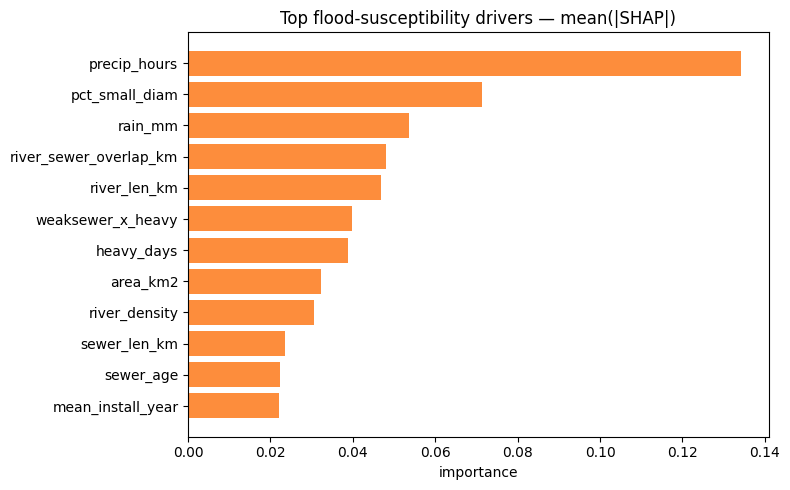

In [4]:
import matplotlib.pyplot as plt
top = imp_df.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top['feature'], top['importance'], color='#fd8d3c')
ax.set_title('Top flood-susceptibility drivers — ' + method)
ax.set_xlabel('importance'); fig.tight_layout()
png = lib.REPO / 'docs' / 'driver_importances.png'
fig.savefig(png, dpi=120, bbox_inches='tight'); print('wrote', png)
plt.show()

## Per-ward susceptibility at recent-typical rainfall

Hold rainfall fixed (mean of 2018–2022) and let the *static infrastructure* features drive the
prediction — isolating which wards are structurally most flood-prone.

In [5]:
import geopandas as gpd
sp = lib.processed_dir() / 'ward_static_features.geojson'
static = gpd.read_file(sp) if sp.exists() else lib.build_ward_static_features()
ref_precip = lib.load_precip_annual().query('year >= 2018')[lib.PRECIP_FEATURES].mean()

ref = pd.DataFrame(static.drop(columns='geometry')).copy()
for c in lib.PRECIP_FEATURES:
    ref[c] = ref_precip[c]
ref['river_x_heavy']       = ref['river_density'] * ref['heavy_days']
ref['weaksewer_x_heavy']   = ref['weak_sewer_km'] * ref['heavy_days']
ref['riveroverlap_x_heavy'] = ref['river_sewer_overlap_km'] * ref['heavy_days']
ref['susceptibility'] = np.expm1(model.predict(ref[lib.MODEL_FEATURES]))

out_csv = lib.processed_dir() / 'ward_susceptibility.csv'
imp_csv = lib.processed_dir() / 'shap_importances.csv'
ref[['ward_num','ward_name','susceptibility']].to_csv(out_csv, index=False)
imp_df.to_csv(imp_csv, index=False)
print('wrote', out_csv); print('wrote', imp_csv)
ref[['ward_num','ward_name','susceptibility']].sort_values('susceptibility', ascending=False).head(10).round(1)

wrote /h/u7/c3/05/fuhrerhu/hidden-rivers/data/processed/ward_susceptibility.csv
wrote /h/u7/c3/05/fuhrerhu/hidden-rivers/data/processed/shap_importances.csv


,ward_num,ward_name,susceptibility
22,5,York South-Weston,462.2
17,8,Eglinton-Lawrence,428.4
4,19,Beaches-East York,392.7
11,15,Don Valley West,348.1
5,20,Scarborough Southwest,332.4
23,14,Toronto-Danforth,327.6
15,3,Etobicoke-Lakeshore,319.8
1,6,York Centre,310.6
9,21,Scarborough Centre,292.6
19,16,Don Valley East,292.0
